# Erdős' Minimum Overlap Problem — Analysis & Verification

This notebook verifies and visualizes step function constructions for the Erdős minimum overlap problem.

**Problem:** Find the largest constant $C_5$ such that
$$\sup_{x \in [-2,2]} \int_{-1}^1 f(t)\, g(x+t)\, dt \geq C_5$$
for all non-negative $f,g: [-1,1] \to [0,1]$ with $f+g=1$ on $[-1,1]$ and $\int f = 1$.

Equivalently ([Haugland 2016](https://arxiv.org/abs/1609.08000)), $C_5$ is the infimum over all step functions $h: [0,2] \to [0,1]$ with $\int_0^2 h(x)\,dx = 1$ of $\max_k \int h(x)(1-h(x+k))\,dx$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, 'solutions')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Verification Functions

A valid step function $h$ must satisfy:
1. All values in $[0, 1]$
2. $\sum_{i} h_i = n/2$ (discrete integral constraint)

The upper bound is computed as $\max_k \frac{2}{n} \sum_i h_i (1 - h_{i+k})$ via cross-correlation.

In [2]:
def verify_sequence(sequence, name=""):
    """Verify that a sequence defines a valid step function and compute its upper bound."""
    seq = np.array(sequence)
    n = len(seq)

    vals_ok = np.all((seq >= 0) & (seq <= 1))
    target_sum = n / 2.0
    actual_sum = np.sum(seq)
    sum_ok = np.isclose(actual_sum, target_sum, atol=1e-6)

    convolution = np.correlate(seq, 1 - seq, mode='full')
    upper_bound = np.max(convolution) / n * 2

    status = "VALID" if (vals_ok and sum_ok) else "INVALID"
    print(f"{name}")
    print(f"  Steps: {n}")
    print(f"  Values in [0,1]: {vals_ok}")
    print(f"  Sum: {actual_sum:.10f} (target: {target_sum:.1f}, {'OK' if sum_ok else 'FAIL'})")
    print(f"  Upper bound: C_5 <= {upper_bound:.15f}")
    print(f"  Status: {status}")
    print()

    return upper_bound, vals_ok and sum_ok


def compute_upper_bound(sequence):
    seq = np.array(sequence)
    convolution = np.correlate(seq, 1 - seq, mode='full')
    return np.max(convolution) / len(seq) * 2

## 2. Load All Solutions

In [3]:
from haugland_2016 import h_values as haugland_h
from alphaevolve_2025 import h_values as alphaevolve_h
from ttt_discover_2026 import h_values as ttt_h
from together_ai_2026 import h_values as together_h

solutions = [
    ("Haugland (2016) — Human Best", haugland_h, 'gray'),
    ("AlphaEvolve (2025) — Google DeepMind", alphaevolve_h, '#C850C0'),
    ("TTT-Discover (2026) — Yuksekgonul et al.", ttt_h, '#1976D2'),
    ("Ours (2026)", together_h, '#E67E22'),
]

## 3. Verify All Solutions

In [4]:
print("=" * 70)
print("VERIFICATION OF ALL STEP FUNCTION CONSTRUCTIONS")
print("=" * 70)
print()

bounds = {}
for name, h, _ in solutions:
    bound, valid = verify_sequence(h, name)
    bounds[name] = bound
    assert valid, f"{name} is INVALID!"

print("=" * 70)
print("All solutions verified successfully.")
print("=" * 70)

VERIFICATION OF ALL STEP FUNCTION CONSTRUCTIONS

Haugland (2016) — Human Best
  Steps: 51
  Values in [0,1]: True
  Sum: 25.5000000000 (target: 25.5, OK)
  Upper bound: C_5 <= 0.380926853433087
  Status: VALID

AlphaEvolve (2025) — Google DeepMind
  Steps: 95
  Values in [0,1]: True
  Sum: 47.5000000000 (target: 47.5, OK)
  Upper bound: C_5 <= 0.380923035108450
  Status: VALID

TTT-Discover (2026) — Yuksekgonul et al.
  Steps: 600
  Values in [0,1]: True
  Sum: 300.0000000000 (target: 300.0, OK)
  Upper bound: C_5 <= 0.380875323217719
  Status: VALID

Ours (2026)
  Steps: 600
  Values in [0,1]: True
  Sum: 300.0000000000 (target: 300.0, OK)
  Upper bound: C_5 <= 0.380870310586220
  Status: VALID

All solutions verified successfully.


## 4. Comparison Table

In [5]:
print(f"{'Method':<45} {'Steps':>6}  {'Upper Bound':>18}")
print("-" * 75)
for name, h, _ in solutions:
    bound = compute_upper_bound(h)
    marker = " <-- NEW SOTA" if name.startswith("Ours") else ""
    print(f"{name:<45} {len(h):>6}  {bound:>18.15f}{marker}")

Method                                         Steps         Upper Bound
---------------------------------------------------------------------------
Haugland (2016) — Human Best                      51   0.380926853433087
AlphaEvolve (2025) — Google DeepMind              95   0.380923035108450
TTT-Discover (2026) — Yuksekgonul et al.         600   0.380875323217719
Ours (2026)                                      600   0.380870310586220 <-- NEW SOTA


## 5. Visualize Step Functions

Each step function $h$ is defined on $[0, 2]$ and is piecewise constant. We plot them normalized to the interval $[-1, 1]$ for easy comparison.

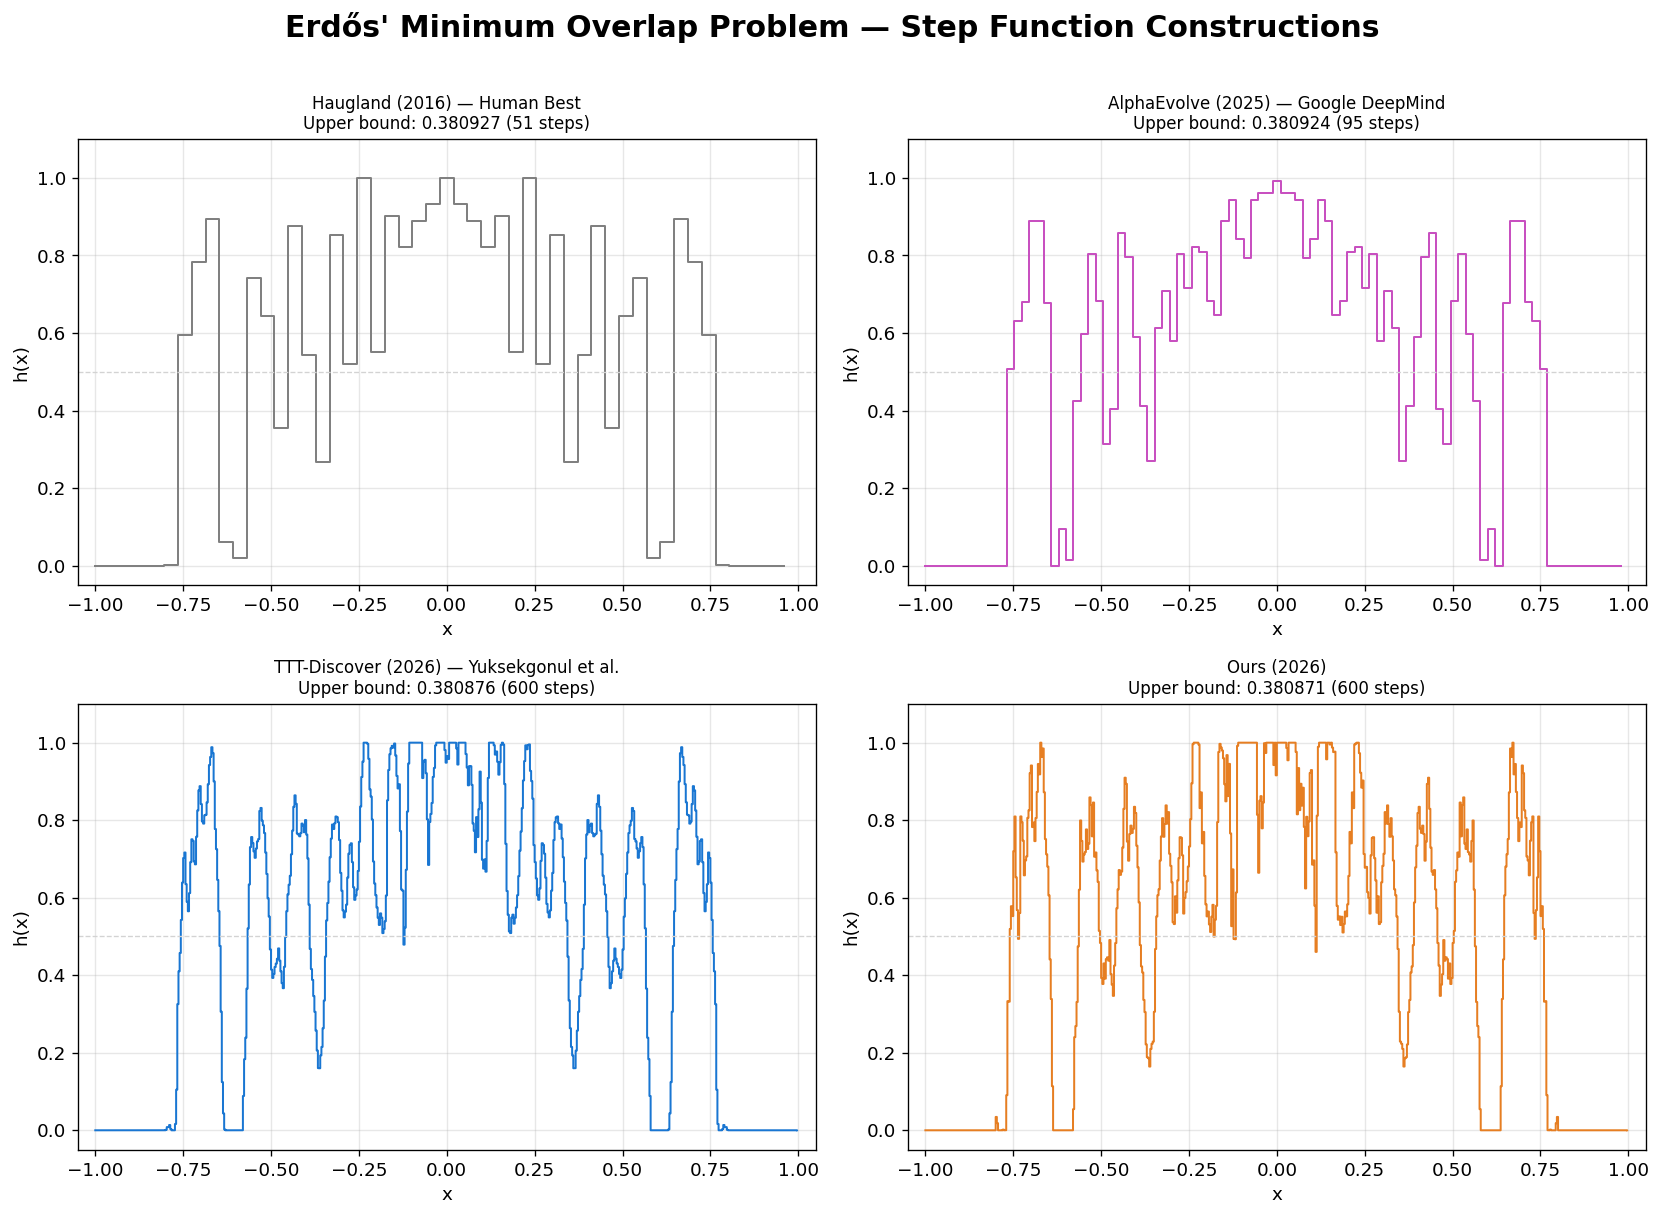

In [6]:
def plot_step_function(ax, seq, title, color):
    """Plot a single step function."""
    n = len(seq)
    edges = np.linspace(-1, 1, n + 1)
    ax.step(edges[:-1], seq, where='post', color=color, linewidth=1.2)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-0.05, 1.1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('h(x)')
    ax.axhline(y=0.5, color='lightgray', linestyle='--', linewidth=0.8)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

import math

def ceil_to_decimals(x, decimals):
    factor = 10 ** decimals
    return math.ceil(x * factor) / factor

for i, (name, h, color) in enumerate(solutions):
    bound = compute_upper_bound(h)
    bound_up = ceil_to_decimals(bound, 6)
    label = f"{name}\nUpper bound: {bound_up:.6f} ({len(h)} steps)"
    plot_step_function(axes[i], h, label, color)

plt.suptitle("Erdős' Minimum Overlap Problem — Step Function Constructions", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()